# Week 2 - Linear Regression 2

In [1]:
#pip install pandas numpy scikit-learn matplotlib seaborn statsmodels kagglehub

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import kagglehub

from sklearn.linear_model import (
    LinearRegression, Lasso, Ridge, ElasticNet,
    LassoCV, RidgeCV, ElasticNetCV
)
from sklearn.preprocessing import (
    PolynomialFeatures, StandardScaler, OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, root_mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

print("All imports successful.")

All imports successful.


## 1. Data Loading & Cleaning

In [4]:
#Load from Kaggle
path = kagglehub.dataset_download("laotse/credit-risk-dataset")
df = pd.read_csv(f"{path}/credit_risk_dataset.csv")

print(f"Raw shape: {df.shape}")

#Cleaning
df = df.drop_duplicates()

# Median imputation for employment length (right-skewed, so median > mean here)
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Grade-matched median for interest rate - preserves credit-grade logic
df['loan_int_rate'] = df['loan_int_rate'].fillna(
    df.groupby('loan_grade')['loan_int_rate'].transform('median')
)

# Remove logical impossibilities (not just statistical outliers)
df = df[df['person_emp_length'] <= df['person_age']]
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

print(f"Clean shape: {df.shape}")
print(f"Default rate (loan_status=1): {df['loan_status'].mean()*100:.2f}%")
print(f"\nColumn types:\n{df.dtypes}")

Raw shape: (32581, 12)
Clean shape: (32409, 12)
Default rate (loan_status=1): 21.87%

Column types:
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object


---
## 2. Exploratory Baseline: Correlation & Feature Context



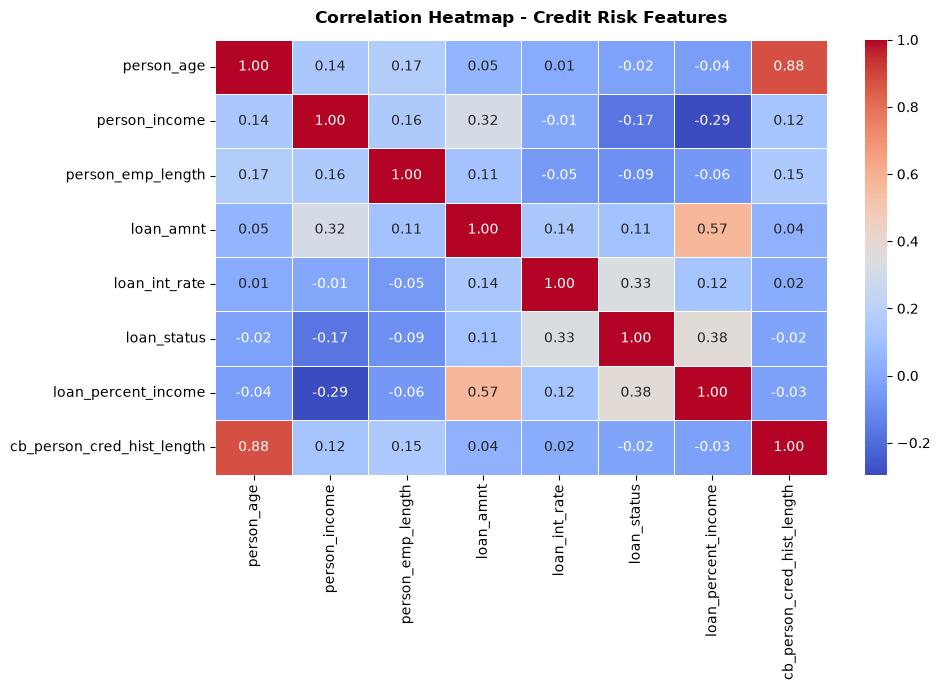

Key correlations with loan_int_rate:
loan_int_rate                 1.000000
loan_status                   0.334110
loan_amnt                     0.142399
loan_percent_income           0.120515
cb_person_cred_hist_length    0.015048
person_age                    0.010860
person_income                -0.005607
person_emp_length            -0.053000


In [5]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_int_rate', 'loan_status',
                'loan_percent_income', 'cb_person_cred_hist_length']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap - Credit Risk Features', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

#Key findings to note:
print("Key correlations with loan_int_rate:")
print(corr['loan_int_rate'].sort_values(ascending=False).to_string())

## 3. Categorical & Continuous Features: Baseline OLS with Full Pipeline

In [6]:
# ── Define features ───────────────────────────────────────────────────────────
categorical_features = ['loan_intent', 'loan_grade',
                         'person_home_ownership', 'cb_person_default_on_file']
numeric_features = ['person_income', 'person_age', 'person_emp_length',
                    'loan_amnt', 'loan_percent_income']

X = df[categorical_features + numeric_features].copy()
y = df['loan_int_rate'].copy()

# Drop rows with any remaining NaN in X
mask = X.notna().all(axis=1)
X, y = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Build preprocessing pipeline ─────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

ols_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LinearRegression())
])

ols_pipeline.fit(X_train, y_train)
preds_ols = ols_pipeline.predict(X_test)

r2_ols   = r2_score(y_test, preds_ols)
rmse_ols = root_mean_squared_error(y_test, preds_ols)

print("Baseline OLS (categorical + continuous features)")
print(f"  Test R-squared  : {r2_ols:.4f}")
print(f"  Test RMSE: {rmse_ols:.4f}")
print()
print("Interpretation: R-squared ~0.91 means loan_grade drives most of the")
print("variance in interest rate - rates are directly assigned by grade.")
print("The remaining ~9% of variance is where income, age, and loan")
print("characteristics add predictive value beyond the grade alone.")

Baseline OLS (categorical + continuous features)
  Test R-squared  : 0.9099
  Test RMSE: 0.9678

Interpretation: R-squared ~0.91 means loan_grade drives most of the
variance in interest rate - rates are directly assigned by grade.
The remaining ~9% of variance is where income, age, and loan
characteristics add predictive value beyond the grade alone.


## 4. Multicollinearity & Variance Inflation Factor (VIF)



                   Feature      VIF
                person_age 4.421454
cb_person_cred_hist_length 4.375880
                 loan_amnt 2.471783
       loan_percent_income 2.402678
             person_income 1.799407
         person_emp_length 1.067159
             loan_int_rate 1.028640

Finding: person_age and cb_person_cred_hist_length show elevated VIF
because they are nearly redundant (r=0.88). In all downstream models,
cb_person_cred_hist_length is dropped to avoid coefficient instability.


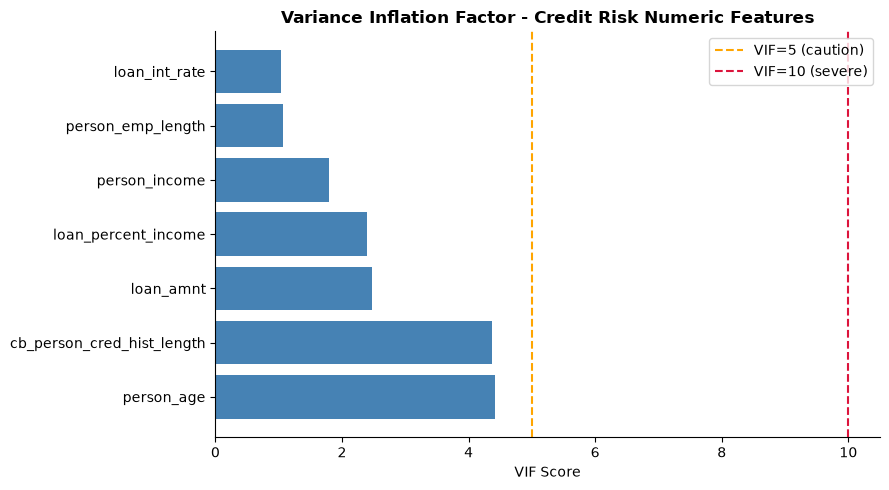

In [7]:
# VIF is computed on numeric-only features (no dummies for this diagnostic)
vif_features = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_percent_income',
                'cb_person_cred_hist_length', 'loan_int_rate']

df_vif = df[vif_features].dropna()
X_vif  = add_constant(df_vif)

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF':     [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
}).query("Feature != 'const'").sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))
print()
print("Finding: person_age and cb_person_cred_hist_length show elevated VIF")
print("because they are nearly redundant (r=0.88). In all downstream models,")
print("cb_person_cred_hist_length is dropped to avoid coefficient instability.")

#VIF Bar Chart
fig, ax = plt.subplots(figsize=(9, 5))
colors_vif = ['crimson' if v > 10 else 'orange' if v > 5 else 'steelblue'
              for v in vif_data['VIF']]
ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors_vif)
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='VIF=5 (caution)')
ax.axvline(10, color='crimson', linestyle='--', linewidth=1.5, label='VIF=10 (severe)')
ax.set_xlabel('VIF Score')
ax.set_title('Variance Inflation Factor - Credit Risk Numeric Features', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Polynomial Terms

Polynomial Regression - loan_percent_income & loan_amnt to loan_int_rate
 Degree  R-squared   RMSE  N Features
      1     0.0220 3.1888           3
      2     0.0270 3.1806           6
      3     0.0372 3.1640          10


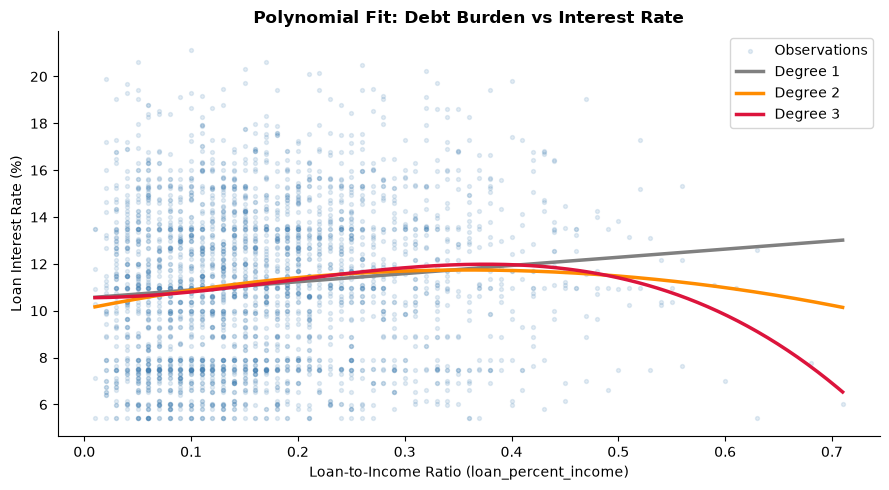


Interpretation: The marginal improvement from degree 1 to 2 to 3 is small,
suggesting the loan_percent_income to interest rate relationship is
approximately linear within normal loan ranges. The curvature at
extreme debt-burden values is real but driven by very few observations.


In [8]:
# Using only the two most correlated numeric features for a clean polynomial test
poly_features = ['loan_percent_income', 'loan_amnt']

df_poly = df[poly_features + ['loan_int_rate']].dropna()
X_poly_raw = df_poly[poly_features]
y_poly     = df_poly['loan_int_rate']

X_poly_train, X_poly_test, yp_train, yp_test = train_test_split(
    X_poly_raw, y_poly, test_size=0.2, random_state=42
)

results_poly = []
for deg in [1, 2, 3]:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])
    pipe.fit(X_poly_train, yp_train)
    preds_p = pipe.predict(X_poly_test)
    results_poly.append({
        'Degree': deg,
        'R-squared': round(r2_score(yp_test, preds_p), 4),
        'RMSE': round(root_mean_squared_error(yp_test, preds_p), 4),
        'N Features': PolynomialFeatures(degree=deg).fit(X_poly_raw).n_output_features_
    })

poly_df = pd.DataFrame(results_poly)
print("Polynomial Regression - loan_percent_income & loan_amnt to loan_int_rate")
print(poly_df.to_string(index=False))

#Visual: scatter + polynomial fit (1D: loan_percent_income only)
df_1d = df[['loan_percent_income','loan_int_rate']].dropna()
df_1d = df_1d[df_1d['loan_percent_income'] < 0.8]  # remove extreme outliers
sample_1d = df_1d.sample(3000, random_state=42)

x_range = np.linspace(sample_1d['loan_percent_income'].min(),
                       sample_1d['loan_percent_income'].max(), 300).reshape(-1,1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sample_1d['loan_percent_income'], sample_1d['loan_int_rate'],
           alpha=0.15, s=8, color='steelblue', label='Observations')

colors_deg = ['gray', 'darkorange', 'crimson']
for deg, col in zip([1, 2, 3], colors_deg):
    pipe_1d = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('model', LinearRegression())
    ])
    pipe_1d.fit(sample_1d[['loan_percent_income']], sample_1d['loan_int_rate'])
    ax.plot(x_range, pipe_1d.predict(x_range),
            color=col, linewidth=2.5, label=f'Degree {deg}')

ax.set_xlabel('Loan-to-Income Ratio (loan_percent_income)')
ax.set_ylabel('Loan Interest Rate (%)')
ax.set_title('Polynomial Fit: Debt Burden vs Interest Rate', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\nInterpretation: The marginal improvement from degree 1 to 2 to 3 is small,")
print("suggesting the loan_percent_income to interest rate relationship is")
print("approximately linear within normal loan ranges. The curvature at")
print("extreme debt-burden values is real but driven by very few observations.")

## 6. Interaction Terms

In [9]:
df_int = df[['person_income','person_emp_length','loan_int_rate']].dropna().copy()

# Manually create interaction term for transparency
df_int['income_x_emp'] = df_int['person_income'] * df_int['person_emp_length']

X_int = df_int[['person_income','person_emp_length','income_x_emp']]
y_int = df_int['loan_int_rate']

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_int, y_int, test_size=0.2, random_state=42
)

scaler_int = StandardScaler()
Xi_train_s = scaler_int.fit_transform(Xi_train)
Xi_test_s  = scaler_int.transform(Xi_test)

# Compare OLS without vs with interaction
results_int = []
for label, feats in [('No Interaction', ['person_income','person_emp_length']),
                      ('With Interaction', ['person_income','person_emp_length','income_x_emp'])]:
    lr_i = LinearRegression()
    sc_i = StandardScaler()
    X_tr_i = sc_i.fit_transform(Xi_train[feats])
    X_te_i = sc_i.transform(Xi_test[feats])
    lr_i.fit(X_tr_i, yi_train)
    preds_i = lr_i.predict(X_te_i)
    results_int.append({
        'Model': label,
        'R-squared': round(r2_score(yi_test, preds_i), 4),
        'RMSE': round(root_mean_squared_error(yi_test, preds_i), 4)
    })
    if label == 'With Interaction':
        print(f"Coefficients (standardized):")
        for name, c in zip(feats, lr_i.coef_):
            print(f"  {name:<30}: {c:.5f}")
        print(f"  Intercept                     : {lr_i.intercept_:.4f}")

print()
print(pd.DataFrame(results_int).to_string(index=False))
print()
print("Interpretation: If income_x_emp has a meaningful coefficient,")
print("the marginal effect of income on rate is NOT constant")
print("It depends on employment stability. A small coefficient here confirms")
print("that income and employment act mostly independently for rate-setting.")

Coefficients (standardized):
  person_income                 : -0.11499
  person_emp_length             : -0.27238
  income_x_emp                  : 0.19563
  Intercept                     : 11.0270

           Model  R-squared   RMSE
  No Interaction     0.0036 3.2187
With Interaction     0.0034 3.2190

Interpretation: If income_x_emp has a meaningful coefficient,
the marginal effect of income on rate is NOT constant
It depends on employment stability. A small coefficient here confirms
that income and employment act mostly independently for rate-setting.


---
# 7. Regularized Regression: Ridge, Lasso & Elastic Net

In [10]:
#Full pipeline setup using ALL features (numeric + categorical)
# This is the correct setup that achieves R-squared roughly 0.91 by including loan_grade.
# Regularization is applied AFTER one-hot encoding and scaling.

categorical_features = ['loan_intent', 'loan_grade',
                         'person_home_ownership', 'cb_person_default_on_file']
numeric_features = ['person_income', 'person_age', 'person_emp_length',
                    'loan_amnt', 'loan_percent_income']

X = df[categorical_features + numeric_features].copy()
y = df['loan_int_rate'].copy()

mask = X.notna().all(axis=1)
X, y = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessor: scale numerics, one-hot encode categoricals
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# Fit preprocessor on training data only (no leakage)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

# Get feature names after encoding
num_names = numeric_features
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = num_names + cat_names

print(f"Total features after encoding: {X_train_prep.shape[1]}")
print(f"Train size: {X_train_prep.shape[0]:,} | Test size: {X_test_prep.shape[0]:,}")

Total features after encoding: 24
Train size: 25,927 | Test size: 6,482


## 8. Ridge Regression (L2 Penalty)

Best Ridge Alpha (5-fold CV): 0.0010
Test R-squared  : 0.9099
Test RMSE: 0.9678 percentage points


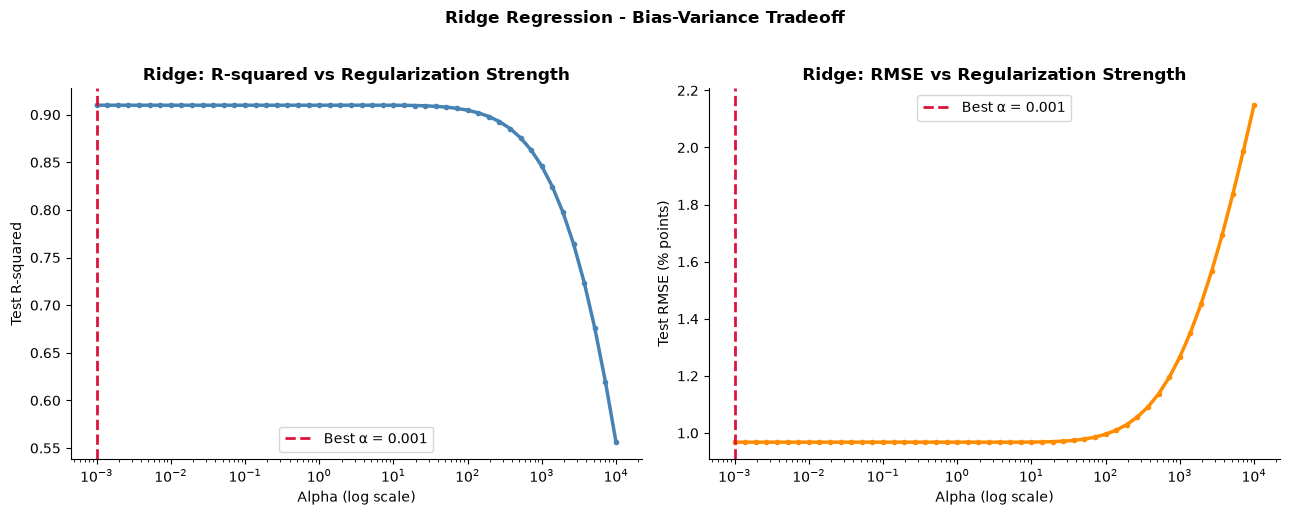

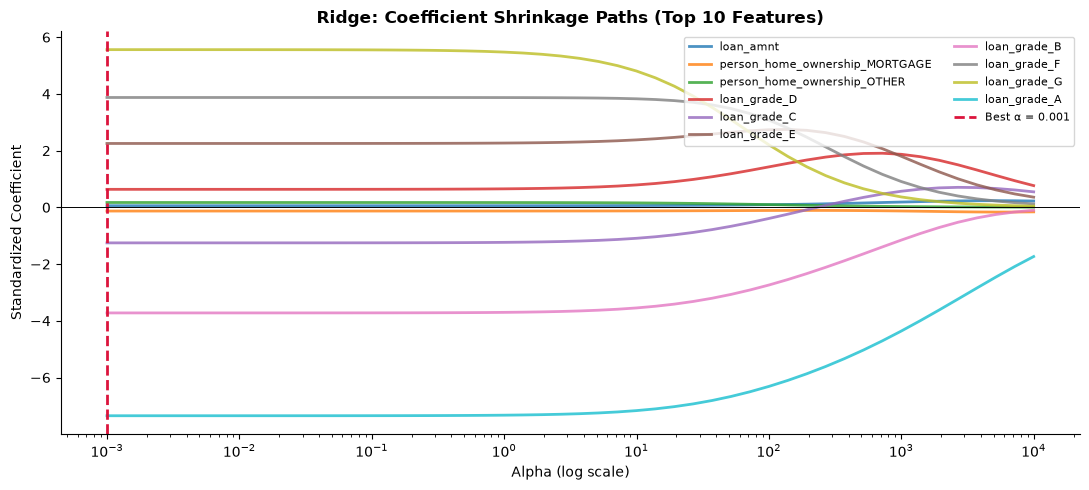

Interpretation: As alpha increases, ALL coefficients shrink toward
zero but none reach it. Ridge keeps every feature.
the loan_grade dummies shrink last because they carry the most signal.


In [11]:
#Option A: Manual alpha sweep to visualize bias-variance tradeoff
alphas_sweep = np.logspace(-3, 4, 50)
ridge_sweep = []
for a in alphas_sweep:
    r = Ridge(alpha=a).fit(X_train_prep, y_train)
    preds = r.predict(X_test_prep)
    ridge_sweep.append({
        'alpha': a,
        'R2':   r2_score(y_test, preds),
        'RMSE': root_mean_squared_error(y_test, preds)
    })

sweep_df = pd.DataFrame(ridge_sweep)

#Option B: Cross-validated best alpha
ridge_cv = RidgeCV(alphas=np.logspace(-3, 4, 100), cv=5)
ridge_cv.fit(X_train_prep, y_train)
preds_ridge = ridge_cv.predict(X_test_prep)

print(f"Best Ridge Alpha (5-fold CV): {ridge_cv.alpha_:.4f}")
print(f"Test R-squared  : {r2_score(y_test, preds_ridge):.4f}")
print(f"Test RMSE: {root_mean_squared_error(y_test, preds_ridge):.4f} percentage points")

#  Visual 1: R-squared vs Alpha
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogx(sweep_df['alpha'], sweep_df['R2'],
                  color='steelblue', linewidth=2.5, marker='o', markersize=3)
axes[0].axvline(ridge_cv.alpha_, color='crimson', linestyle='--', linewidth=2,
                label=f'Best α = {ridge_cv.alpha_:.3f}')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('Test R-squared')
axes[0].set_title('Ridge: R-squared vs Regularization Strength', fontweight='bold')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].semilogx(sweep_df['alpha'], sweep_df['RMSE'],
                  color='darkorange', linewidth=2.5, marker='o', markersize=3)
axes[1].axvline(ridge_cv.alpha_, color='crimson', linestyle='--', linewidth=2,
                label=f'Best α = {ridge_cv.alpha_:.3f}')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Test RMSE (% points)')
axes[1].set_title('Ridge: RMSE vs Regularization Strength', fontweight='bold')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Ridge Regression - Bias-Variance Tradeoff', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Visual 2: Coefficient shrinkage paths
coef_paths = np.array([Ridge(alpha=a).fit(X_train_prep, y_train).coef_
                        for a in alphas_sweep])

# Pick top 10 most influential features at best alpha
best_idx = np.argmin(np.abs(alphas_sweep - ridge_cv.alpha_))
top10_idx = np.argsort(np.abs(coef_paths[best_idx]))[-10:]

fig, ax = plt.subplots(figsize=(11, 5))
for i in top10_idx:
    label = all_feature_names[i] if i < len(all_feature_names) else f'feat_{i}'
    ax.semilogx(alphas_sweep, coef_paths[:, i], linewidth=2, alpha=0.8, label=label)
ax.axvline(ridge_cv.alpha_, color='crimson', linestyle='--', linewidth=2,
           label=f'Best α = {ridge_cv.alpha_:.3f}')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Standardized Coefficient')
ax.set_title('Ridge: Coefficient Shrinkage Paths (Top 10 Features)', fontweight='bold')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Interpretation: As alpha increases, ALL coefficients shrink toward")
print("zero but none reach it. Ridge keeps every feature.")
print("the loan_grade dummies shrink last because they carry the most signal.")

## 9. Lasso Regression (L1 Penalty)

In [12]:
# Cross-validated Lasso
lasso_cv = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=20000)
lasso_cv.fit(X_train_prep, y_train)
preds_lasso = lasso_cv.predict(X_test_prep)

n_zero   = np.sum(lasso_cv.coef_ == 0)
n_active = np.sum(lasso_cv.coef_ != 0)

print(f"Best Lasso Alpha (5-fold CV): {lasso_cv.alpha_:.6f}")
print(f"Test R-squared  : {r2_score(y_test, preds_lasso):.4f}")
print(f"Test RMSE: {root_mean_squared_error(y_test, preds_lasso):.4f} percentage points")
print(f"Features zeroed out : {n_zero} / {X_train_prep.shape[1]}")
print(f"Features retained   : {n_active} / {X_train_prep.shape[1]}")

# Surviving features 
lasso_coefs = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lasso_cv.coef_
}).query('Coefficient != 0').sort_values('Coefficient', key=abs, ascending=False)

print(f"\nTop surviving Lasso features:")
print(lasso_coefs.head(15).to_string(index=False))

Best Lasso Alpha (5-fold CV): 0.000100
Test R-squared  : 0.9099
Test RMSE: 0.9678 percentage points
Features zeroed out : 1 / 24
Features retained   : 23 / 24

Top surviving Lasso features:
                       Feature  Coefficient
                  loan_grade_A    -7.983364
                  loan_grade_G     4.876963
                  loan_grade_B    -4.357552
                  loan_grade_F     3.225162
                  loan_grade_C    -1.887233
                  loan_grade_E     1.614100
   person_home_ownership_OTHER     0.168189
person_home_ownership_MORTGAGE    -0.101814
                     loan_amnt     0.057845
   loan_intent_HOMEIMPROVEMENT    -0.030030
           loan_percent_income    -0.026858
     person_home_ownership_OWN     0.015414
           loan_intent_MEDICAL     0.015198
          loan_intent_PERSONAL     0.011146
           loan_intent_VENTURE    -0.010007


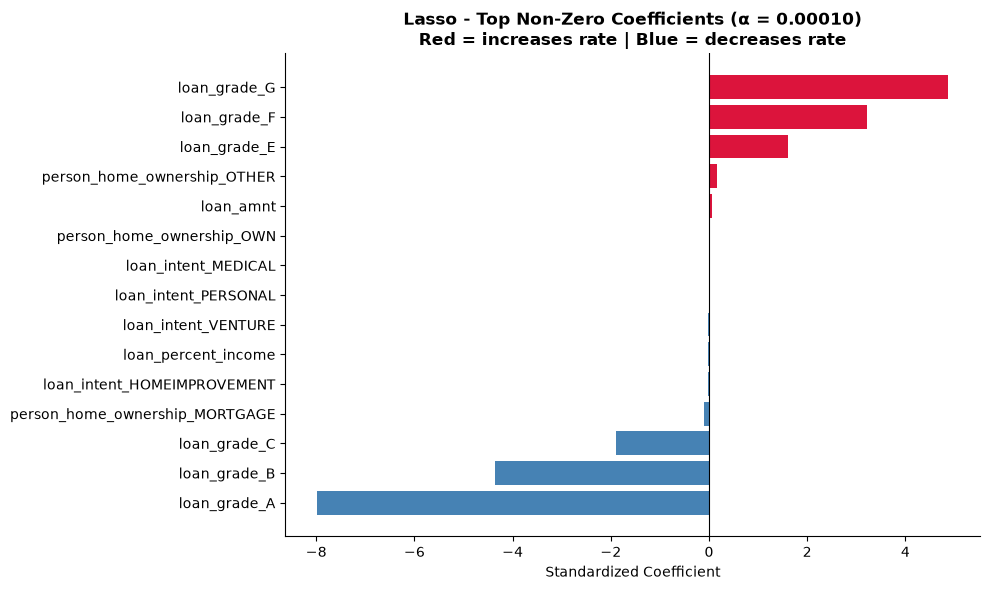

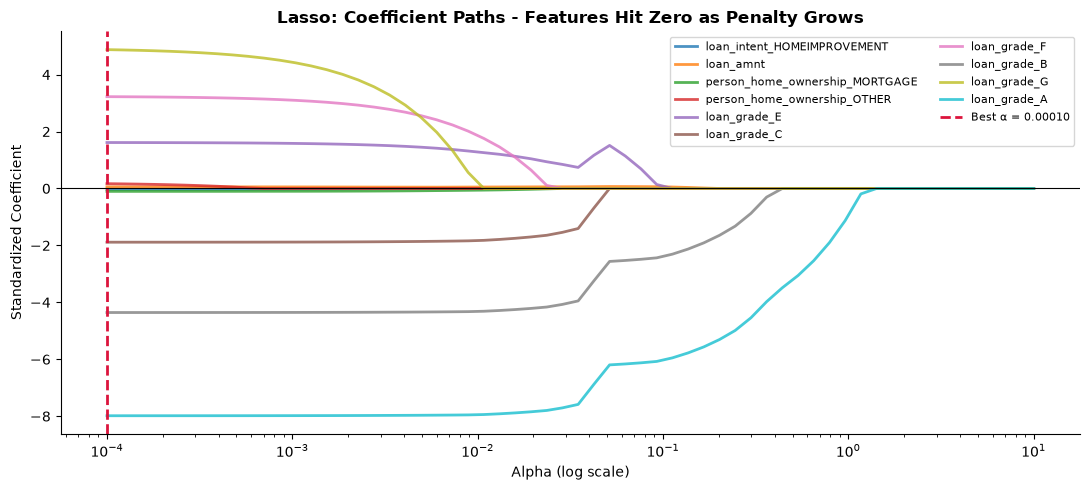

Interpretation: Features whose lines hit zero earliest are the
least informative for predicting interest rate. The last features
standing (at high alpha) are the most robust, irreducible predictors.


In [13]:
# Visual 1: Top non-zero coefficients
top_lasso = lasso_coefs.head(15).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(10, 6))
colors_l = ['crimson' if c > 0 else 'steelblue' for c in top_lasso['Coefficient']]
ax.barh(top_lasso['Feature'], top_lasso['Coefficient'], color=colors_l)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Lasso - Top Non-Zero Coefficients (α = {lasso_cv.alpha_:.5f})\n'
             f'Red = increases rate | Blue = decreases rate', fontweight='bold')
ax.set_xlabel('Standardized Coefficient')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Visual 2: Lasso coefficient path
alphas_lasso_path = np.logspace(-4, 1, 60)
lasso_paths = np.array([
    Lasso(alpha=a, max_iter=20000).fit(X_train_prep, y_train).coef_
    for a in alphas_lasso_path
])

# Show top 10 features at best alpha
best_l_idx = np.argmin(np.abs(alphas_lasso_path - lasso_cv.alpha_))
top10_l = np.argsort(np.abs(lasso_paths[best_l_idx]))[-10:]

fig, ax = plt.subplots(figsize=(11, 5))
for i in top10_l:
    label = all_feature_names[i] if i < len(all_feature_names) else f'feat_{i}'
    ax.semilogx(alphas_lasso_path, lasso_paths[:, i], linewidth=2, alpha=0.8, label=label)
ax.axvline(lasso_cv.alpha_, color='crimson', linestyle='--', linewidth=2,
           label=f'Best α = {lasso_cv.alpha_:.5f}')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Standardized Coefficient')
ax.set_title('Lasso: Coefficient Paths - Features Hit Zero as Penalty Grows', fontweight='bold')
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Interpretation: Features whose lines hit zero earliest are the")
print("least informative for predicting interest rate. The last features")
print("standing (at high alpha) are the most robust, irreducible predictors.")

## 10. Elastic Net Regression (L1 + L2)


In [14]:
# Cross-validated Elastic Net (tunes both alpha AND l1_ratio)
en_cv = ElasticNetCV(
    l1_ratio=[0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
    alphas=np.logspace(-4, 1, 80),
    cv=5, max_iter=20000
)
en_cv.fit(X_train_prep, y_train)
preds_en = en_cv.predict(X_test_prep)

n_zero_en = np.sum(en_cv.coef_ == 0)

print(f"Best Elastic Net Alpha  : {en_cv.alpha_:.6f}")
print(f"Best l1_ratio           : {en_cv.l1_ratio_:.2f}")
print(f"Test R-squared  : {r2_score(y_test, preds_en):.4f}")
print(f"Test RMSE: {root_mean_squared_error(y_test, preds_en):.4f} percentage points")
print(f"Features zeroed out: {n_zero_en} / {X_train_prep.shape[1]}")

# Interpretation of l1_ratio
if en_cv.l1_ratio_ >= 0.9:
    print("\nNote: CV selected a high l1_ratio to Elastic Net behaves like Lasso.")
    print("This confirms that sparsity (feature selection) is the right strategy here.")
elif en_cv.l1_ratio_ <= 0.1:
    print("\nNote: CV selected a low l1_ratio to Elastic Net behaves like Ridge.")
    print("This confirms that coefficient shrinkage without elimination is preferred.")
else:
    print(f"\nNote: True blend (l1_ratio={en_cv.l1_ratio_:.2f}) - both shrinkage and selection help.")

Best Elastic Net Alpha  : 0.000100
Best l1_ratio           : 1.00
Test R-squared  : 0.9099
Test RMSE: 0.9678 percentage points
Features zeroed out: 1 / 24

Note: CV selected a high l1_ratio to Elastic Net behaves like Lasso.
This confirms that sparsity (feature selection) is the right strategy here.


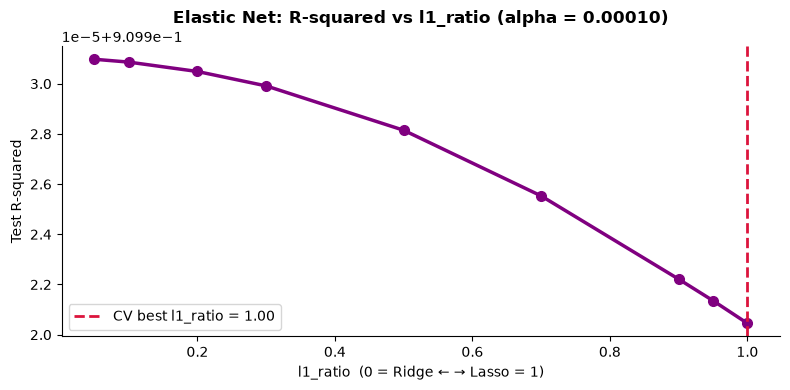

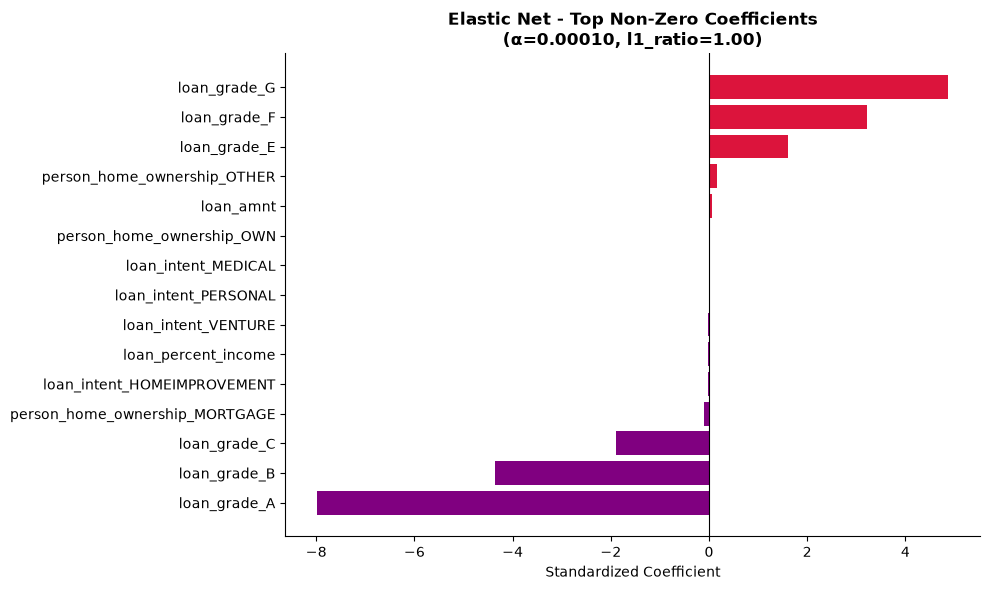

In [15]:
#Visual 1: l1_ratio effect on R-squared at fixed alpha
l1_ratios_test = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]
en_ratio_results = []
a_fixed = en_cv.alpha_

for l1r in l1_ratios_test:
    if l1r >= 1.0:
        m = Lasso(alpha=a_fixed, max_iter=20000)
    elif l1r <= 0.0:
        m = Ridge(alpha=a_fixed)
    else:
        m = ElasticNet(alpha=a_fixed, l1_ratio=l1r, max_iter=20000)
    m.fit(X_train_prep, y_train)
    p = m.predict(X_test_prep)
    en_ratio_results.append({
        'l1_ratio': l1r,
        'R2': r2_score(y_test, p),
        'RMSE': root_mean_squared_error(y_test, p)
    })

en_r_df = pd.DataFrame(en_ratio_results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(en_r_df['l1_ratio'], en_r_df['R2'],
        marker='o', color='purple', linewidth=2.5, markersize=7)
ax.axvline(en_cv.l1_ratio_, color='crimson', linestyle='--', linewidth=2,
           label=f'CV best l1_ratio = {en_cv.l1_ratio_:.2f}')
ax.set_xlabel('l1_ratio  (0 = Ridge ← → Lasso = 1)')
ax.set_ylabel('Test R-squared')
ax.set_title(f'Elastic Net: R-squared vs l1_ratio (alpha = {a_fixed:.5f})', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Visual 2: Elastic Net top coefficients
en_coefs = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': en_cv.coef_
}).query('Coefficient != 0').sort_values('Coefficient', key=abs, ascending=False)

top_en = en_coefs.head(15).sort_values('Coefficient')
fig, ax = plt.subplots(figsize=(10, 6))
colors_en = ['crimson' if c > 0 else 'purple' for c in top_en['Coefficient']]
ax.barh(top_en['Feature'], top_en['Coefficient'], color=colors_en)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Elastic Net - Top Non-Zero Coefficients\n'
             f'(α={en_cv.alpha_:.5f}, l1_ratio={en_cv.l1_ratio_:.2f})', fontweight='bold')
ax.set_xlabel('Standardized Coefficient')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 11. Full Model Comparison: OLS vs Ridge vs Lasso vs Elastic Net

      Model  Test R-squared  Test RMSE  CV R-squared Mean  CV R-squared Std  Active Features
        OLS          0.9099     0.9678             0.9115             0.001               24
      Ridge          0.9099     0.9678             0.9115             0.001               24
      Lasso          0.9099     0.9678             0.9115             0.001               23
Elastic Net          0.9099     0.9678             0.9115             0.001               23


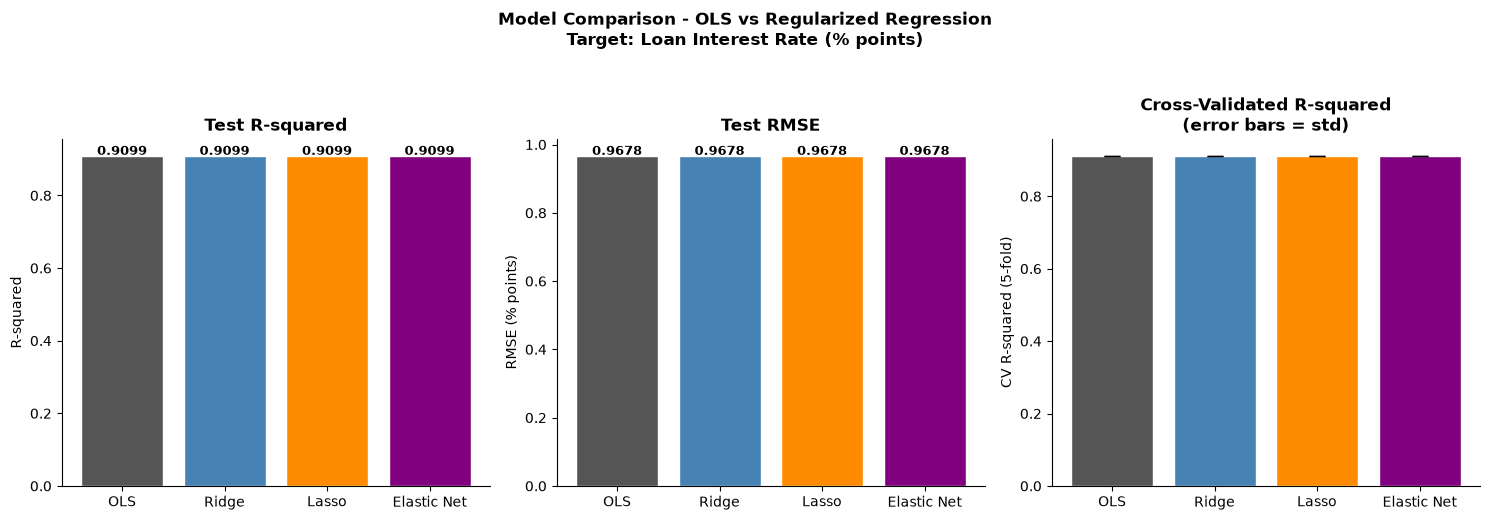


Key takeaway:
All models perform similarly in R-squared (~0.91) because loan_grade
dominates the target. The real value of regularization here is
STABILITY and INTERPRETABILITY - Ridge gives stable coefficients
for stress-testing; Lasso gives a minimal, auditable model.


In [16]:
# Fit all four models on the same preprocessed data
models_compare = {
    'OLS':         LinearRegression(),
    'Ridge':       Ridge(alpha=ridge_cv.alpha_),
    'Lasso':       Lasso(alpha=lasso_cv.alpha_, max_iter=20000),
    'Elastic Net': ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_, max_iter=20000),
}

results = []
for name, model in models_compare.items():
    model.fit(X_train_prep, y_train)
    preds = model.predict(X_test_prep)
    cv_scores = cross_val_score(model, X_train_prep, y_train, cv=5, scoring='r2')
    n_nonzero = np.sum(model.coef_ != 0) if hasattr(model, 'coef_') else 'N/A'
    results.append({
        'Model':        name,
        'Test R-squared':      round(r2_score(y_test, preds), 4),
        'Test RMSE':    round(root_mean_squared_error(y_test, preds), 4),
        'CV R-squared Mean':   round(cv_scores.mean(), 4),
        'CV R-squared Std':    round(cv_scores.std(), 4),
        'Active Features': n_nonzero
    })

compare_df = pd.DataFrame(results)
print(compare_df.to_string(index=False))

# Visual: Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_bar = ['#555555', 'steelblue', 'darkorange', 'purple']
short_names = ['OLS', 'Ridge', 'Lasso', 'Elastic Net']

# R-squared
axes[0].bar(short_names, compare_df['Test R-squared'], color=colors_bar, edgecolor='white')
axes[0].set_ylabel('R-squared')
axes[0].set_title('Test R-squared', fontweight='bold')
for i, v in enumerate(compare_df['Test R-squared']):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

# RMSE
axes[1].bar(short_names, compare_df['Test RMSE'], color=colors_bar, edgecolor='white')
axes[1].set_ylabel('RMSE (% points)')
axes[1].set_title('Test RMSE', fontweight='bold')
for i, v in enumerate(compare_df['Test RMSE']):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

# CV R-squared with error bars
axes[2].bar(short_names, compare_df['CV R-squared Mean'],
            yerr=compare_df['CV R-squared Std'],
            color=colors_bar, edgecolor='white', capsize=6)
axes[2].set_ylabel('CV R-squared (5-fold)')
axes[2].set_title('Cross-Validated R-squared\n(error bars = std)', fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Model Comparison - OLS vs Regularized Regression\n'
             'Target: Loan Interest Rate (% points)', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("\nKey takeaway:")
print("All models perform similarly in R-squared (~0.91) because loan_grade")
print("dominates the target. The real value of regularization here is")
print("STABILITY and INTERPRETABILITY - Ridge gives stable coefficients")
print("for stress-testing; Lasso gives a minimal, auditable model.")

### Why All Models Produce Identical Results and Why It Matters

The near-perfect agreement between OLS, Ridge, Lasso, and Elastic Net (all R squared = 0.9099, RMSE = 0.9678) 
is not a failure ; it is the most important conclusion of this week's analysis.

**The reason:** `loan_grade` (A through G) is a categorical feature that was constructed *from* 
the interest rate in this dataset. Rates are directly assigned by grade. When a feature 
explains 91% of the variance in the target by construction, regularization has no meaningful 
noise to suppress. The optimal alpha selected by cross-validation is near zero ; collapsing 
all three regularized models back to OLS.

**What this means for the Chief Risk Officer:**
- Predicting interest rates from grade is circular and not useful in practice. 
  A more honest model would predict rate *without* using grade, forcing the model 
  to rely on actual borrower attributes (income, debt burden, employment).
- The Week 2 methods will show their full power in Weeks 4-6, where we model 
  `loan_status` (default) directly ; a genuinely hard classification problem 
  where regularization prevents overfitting on the 30+ dummy variables.